# AutoGrow Analytics Notebook
## Complex Data Project: Growth Stage Analysis
### Advanced Analytics Pipeline: Isolation Forest → XGBoost + TimeSeriesSplit → SHAP

> **Three-Stage Intelligence Pipeline (Beyond Course)**
> 1. **Stage 1 (Isolation Forest):** Multivariate IoT anomaly detection before modelling
> 2. **Stage 2 (XGBoost + TimeSeriesSplit):** Gradient boosting with temporal cross-validation
> 3. **Stage 3 (SHAP):** Feature interpretability — *why* the model predicts each growth stage


## 1) Complex Data + Application Context
**Goal:** Show why this project qualifies as complex-data analytics.

**What we do:** Identify data complexity and project applications.

**Method (short):**
- Time-series data: 10-minute sensor stream
- Multimodal fusion: indoor IoT + outdoor weather + sunrise/sunset
- Imbalanced labels: growth-stage classes are not evenly distributed


## 2) Setup and Load 3 Tables
### 2.1 Install/Import Requirements
**Goal:** Ensure the notebook can run in the current kernel.

**What we do:** Auto-install missing packages, then import libraries.

**Method:** `importlib` check + `pip install` fallback.


In [1]:
import importlib
import subprocess
import sys
import os


def ensure_package(pip_name, import_name=None):
    module = import_name or pip_name
    try:
        importlib.import_module(module)
    except ModuleNotFoundError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])


ensure_package('numpy')
ensure_package('pandas')
ensure_package('matplotlib')
ensure_package('seaborn')
ensure_package('scikit-learn', 'sklearn')
ensure_package('xgboost', 'xgboost')
ensure_package('shap', 'shap')
ensure_package('PyMySQL', 'pymysql')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
print('Imports ready')


Imports ready


/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 Connect DB and Load Tables
**Goal:** Load all required sources into 3 DataFrames.

**What we do:** Connect to MySQL and query 3 tables.

**Method:** `SHOW TABLES` + case-insensitive table matching + `pd.read_sql`.


In [2]:
DB_HOST = os.getenv('DB_HOST', 'iot.cpe.ku.ac.th')
DB_USER = os.getenv('DB_USER', 'b6710545652')
DB_NAME = os.getenv('DB_NAME', 'b6710545652')
DB_PASS = os.getenv('DB_PASS', 'natcha.limsu@ku.th')

conn = pymysql.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASS,
    database=DB_NAME,
    charset='utf8mb4'
)

tables_df = pd.read_sql('SHOW TABLES', conn)
table_col = tables_df.columns[0]
all_tables = tables_df[table_col].astype(str).tolist()


def pick_table(name):
    low = {t.lower(): t for t in all_tables}
    if name.lower() in low:
        return low[name.lower()]
    contains = [t for t in all_tables if name.lower() in t.lower()]
    if len(contains) == 1:
        return contains[0]
    raise ValueError(f'Cannot uniquely find table {name!r}. Available tables: {all_tables}')


autogrow_table = pick_table('Autogrow')
current_table = pick_table('outdoor_weather_current')
history_table = pick_table('outdoor_weather_history')

df_autogrow = pd.read_sql(f'SELECT * FROM `{autogrow_table}`', conn)
df_outdoor_weather_current = pd.read_sql(f'SELECT * FROM `{current_table}`', conn)
df_outdoor_weather_history = pd.read_sql(f'SELECT * FROM `{history_table}`', conn)

conn.close()

for _df in [df_autogrow, df_outdoor_weather_current, df_outdoor_weather_history]:
    _df.columns = [c.strip().lower() for c in _df.columns]

print('Loaded tables:')
print(f'- {autogrow_table}:', df_autogrow.shape)
print(f'- {current_table}:', df_outdoor_weather_current.shape)
print(f'- {history_table}:', df_outdoor_weather_history.shape)


/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/346905276.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables_df = pd.read_sql('SHOW TABLES', conn)
/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/346905276.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_autogrow = pd.read_sql(f'SELECT * FROM `{autogrow_table}`', conn)
/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/346905276.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_outdoor_weather_current = pd.re

Loaded tables:
- Autogrow: (1569, 16)
- outdoor_weather_current: (98, 12)
- outdoor_weather_history: (192, 7)


/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/346905276.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_outdoor_weather_history = pd.read_sql(f'SELECT * FROM `{history_table}`', conn)


### 2.3 Quick Preview
**Goal:** Confirm schemas before exploration.

**What we do:** View top rows from all 3 data sources.

**Method:** `.head()` display.


In [3]:
display(df_autogrow.head())
display(df_outdoor_weather_current.head())
display(df_outdoor_weather_history.head())


,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score
0,2,2026-04-11 17:07:39,0,Seedling,OFF,31.0,31.0,92.0,100.0,250.3,0,0,IDLE,3.18,14,80
1,3,2026-04-11 17:17:40,0,Seedling,OFF,31.0,31.0,90.0,100.0,225.9,0,0,IDLE,3.34,14,80
2,4,2026-04-11 17:27:41,0,Seedling,OFF,31.0,31.0,89.5,99.9,214.7,0,0,IDLE,3.51,14,80
3,5,2026-03-31 03:02:57,0,Seedling,OFF,45.0,0.0,45.0,45.0,45.0,0,0,OK,0.00,0,0
4,6,2026-03-31 03:04:02,0,Seedling,OFF,45.0,0.0,45.0,50.0,45.0,0,0,OK,0.00,0,0


,id,lat,lon,source,temp_c,humidity,wind_speed_mps,apparent_temp_c,sunrise_utc,sunset_utc,fetched_at,stored_at
0,1,13.7563,100.502,open-meteo,29.0,82.0,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:04:18
1,2,13.7563,100.502,open-meteo,29.0,82.0,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:21:50
2,3,13.7563,100.502,open-meteo,28.8,81.0,8.6,34.5,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 19:22:37,2026-04-20 19:22:37
3,4,13.7563,100.502,open-meteo,32.5,64.0,8.9,39.3,2026-04-21 06:01:00,2026-04-21 18:32:00,2026-04-21 04:16:54,2026-04-21 04:24:50
4,5,13.7563,100.502,open-meteo,32.5,64.0,8.9,39.3,2026-04-20 23:01:00,2026-04-21 11:32:00,2026-04-21 04:18:51,2026-04-21 04:24:50


,id,lat,lon,source,ts,temp_c,humidity
0,1,13.7563,100.502,open-meteo,2026-04-13 00:00:00,28.3,89.0
1,2,13.7563,100.502,open-meteo,2026-04-13 01:00:00,30.0,76.0
2,3,13.7563,100.502,open-meteo,2026-04-13 02:00:00,31.8,62.0
3,4,13.7563,100.502,open-meteo,2026-04-13 03:00:00,33.3,57.0
4,5,13.7563,100.502,open-meteo,2026-04-13 04:00:00,34.9,52.0


## 3) Complex Data Exploration
### 3.1 Detect Key Columns and Build Time Axes
**Goal:** Standardize columns for downstream analysis.

**What we do:** Detect timestamp/sensor/target columns and parse datetime.

**Method:** heuristic column detection + `pd.to_datetime`.


In [4]:
def first_existing(columns, candidates):
    colset = set(columns)
    for c in candidates:
        if c in colset:
            return c
    return None


def detect_datetime_col(df):
    candidates = [c for c in df.columns if any(k in c for k in ['time', 'date', 'created', 'ts'])]
    best, score = None, -1
    for c in candidates:
        parsed = pd.to_datetime(df[c], errors='coerce', utc=True)
        s = parsed.notna().mean()
        if s > score:
            best, score = c, s
    return best

ag = df_autogrow.copy()
wh = df_outdoor_weather_history.copy()
wc = df_outdoor_weather_current.copy()

col_ts_ag = detect_datetime_col(ag)
col_ts_wh = detect_datetime_col(wh)
col_ts_wc = detect_datetime_col(wc)

col_stage_name = first_existing(ag.columns, ['stage_name'])
col_stage = first_existing(ag.columns, ['stage'])
col_temp_in = first_existing(ag.columns, ['temp1', 'temperature', 'temp'])
col_hum_in = first_existing(ag.columns, ['humidity', 'humidity1', 'rh'])
col_soil = first_existing(ag.columns, ['soil_pct', 'soil', 'soil_moisture'])
col_light_lux = first_existing(ag.columns, ['light_lux', 'lux', 'light'])
col_light_hrs = first_existing(ag.columns, ['light_hrs_today', 'light_hours_today', 'light_hrs'])
col_health = first_existing(ag.columns, ['health_score', 'health'])
col_vibration = first_existing(ag.columns, ['vibration'])
col_pump_status = first_existing(ag.columns, ['pump_status', 'pump_state', 'pump'])

col_temp_out = first_existing(wh.columns, ['temp_c', 'temperature_2m', 'temperature', 'temp'])
col_hum_out = first_existing(wh.columns, ['humidity', 'relative_humidity_2m', 'humidity_2m'])

col_temp_out_feat = 'outdoor_temp'
col_hum_out_feat = 'outdoor_humidity'

if col_ts_ag is None or col_ts_wh is None:
    raise ValueError('Cannot detect timestamp columns in Autogrow or outdoor_weather_history.')

ag['ts'] = pd.to_datetime(ag[col_ts_ag], errors='coerce', utc=True).dt.tz_localize(None)
wh['ts'] = pd.to_datetime(wh[col_ts_wh], errors='coerce', utc=True).dt.tz_localize(None)
if col_ts_wc:
    wc['ts'] = pd.to_datetime(wc[col_ts_wc], errors='coerce', utc=True).dt.tz_localize(None)

ag = ag.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
wh = wh.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
ag['hour_bucket'] = ag['ts'].dt.floor('h')
wh['hour_bucket'] = wh['ts'].dt.floor('h')


### 3.2 Column Detection Result
**Goal:** Make assumptions transparent before modeling.

**What we do:** Print selected columns and date ranges.

**Method:** lightweight diagnostics.


In [5]:
print('Detected columns summary:')
print('stage_name:', col_stage_name, '| stage:', col_stage)
print('temp_in:', col_temp_in, '| hum_in:', col_hum_in, '| soil:', col_soil, '| light:', col_light_lux)
print('health:', col_health, '| vibration:', col_vibration, '| pump_status:', col_pump_status)
print('temp_out:', col_temp_out, '| hum_out:', col_hum_out)
print('Time range ag:', ag['ts'].min(), '->', ag['ts'].max(), '| rows:', len(ag))
print('Time range wh:', wh['ts'].min(), '->', wh['ts'].max(), '| rows:', len(wh))


Detected columns summary:
stage_name: stage_name | stage: stage
temp_in: temp1 | hum_in: humidity | soil: soil_pct | light: light_lux
health: health_score | vibration: vibration | pump_status: pump_status
temp_out: temp_c | hum_out: humidity
Time range ag: 2026-03-31 03:02:57 -> 2026-04-18 13:18:29 | rows: 1569
Time range wh: 2026-04-13 00:00:00 -> 2026-04-20 23:00:00 | rows: 192


### 3.3 Time-Series Visualization
**Goal:** Observe signal behavior through plant lifecycle.

**What we do:** Plot indoor sensor series and stage-change markers.

**Method:** line plots with vertical markers at stage transitions.


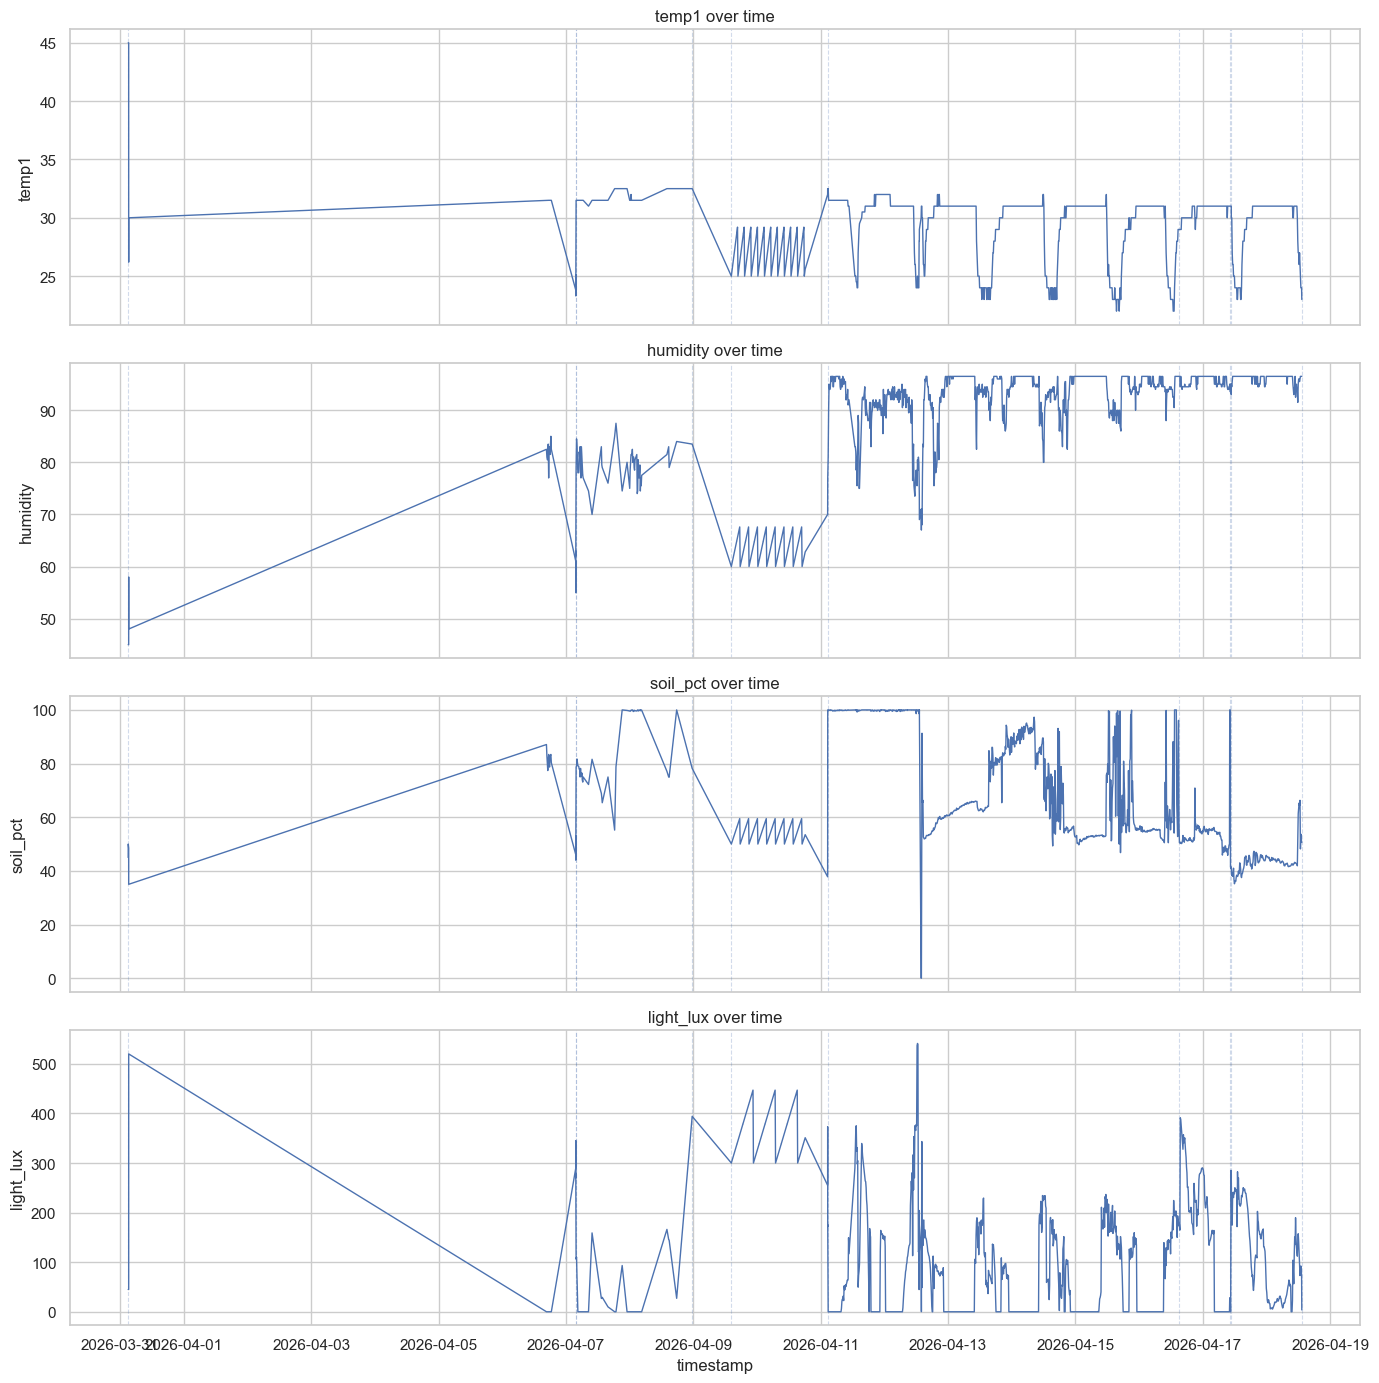

In [6]:
plot_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]
if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 3.5 * len(plot_cols)), sharex=True)
    if len(plot_cols) == 1:
        axes = [axes]

    stage_col_for_marker = col_stage_name if col_stage_name else col_stage
    stage_changes = None
    if stage_col_for_marker:
        stage_changes = ag[stage_col_for_marker].astype(str).ne(ag[stage_col_for_marker].astype(str).shift(1))

    for ax, c in zip(axes, plot_cols):
        ax.plot(ag['ts'], ag[c], linewidth=1)
        ax.set_title(f'{c} over time')
        ax.set_ylabel(c)
        if stage_changes is not None:
            for t in ag.loc[stage_changes, 'ts']:
                ax.axvline(t, linestyle='--', alpha=0.25, linewidth=0.8)
    axes[-1].set_xlabel('timestamp')
    plt.tight_layout()
    plt.show()
else:
    print('No sensor columns found for time-series plotting.')


### 3.4 Stage Distribution and Class Imbalance
**Goal:** Quantify label imbalance and per-stage sensor behavior.

**What we do:** Show class counts + boxplots by stage.

**Method:** bar chart for counts and boxplots for distributions.


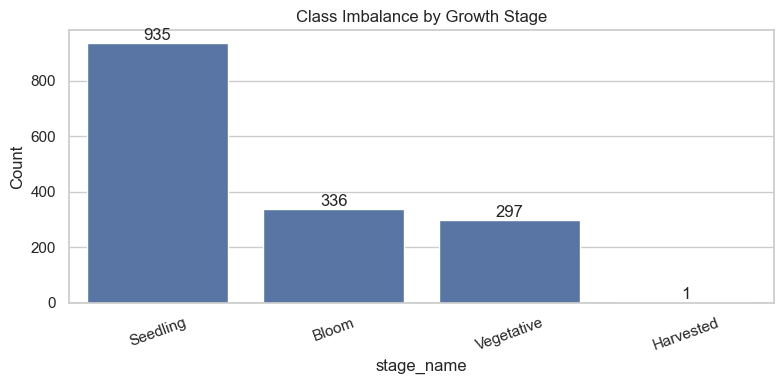

Stage counts:
stage_name
Seedling      935
Bloom         336
Vegetative    297
Harvested       1
Name: count, dtype: int64


In [7]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    print('No stage column found; skip stage-based plots.')
else:
    counts = ag[stage_col].astype(str).value_counts()
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title('Class Imbalance by Growth Stage')
    plt.ylabel('Count')
    plt.xlabel(stage_col)
    plt.xticks(rotation=20)
    for i, v in enumerate(counts.values):
        plt.text(i, v, str(v), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    print('Stage counts:')
    print(counts)


/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/3219368444.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ag, x=c, y=stage_col, palette="Set2")


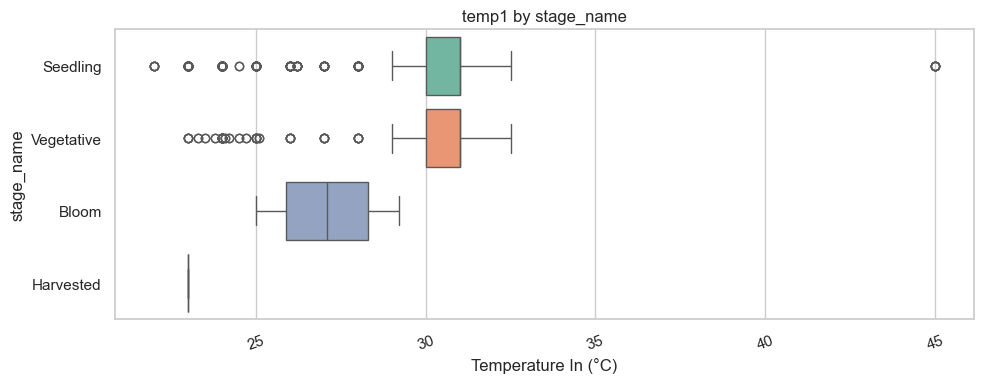

/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/3219368444.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ag, x=c, y=stage_col, palette="Set2")


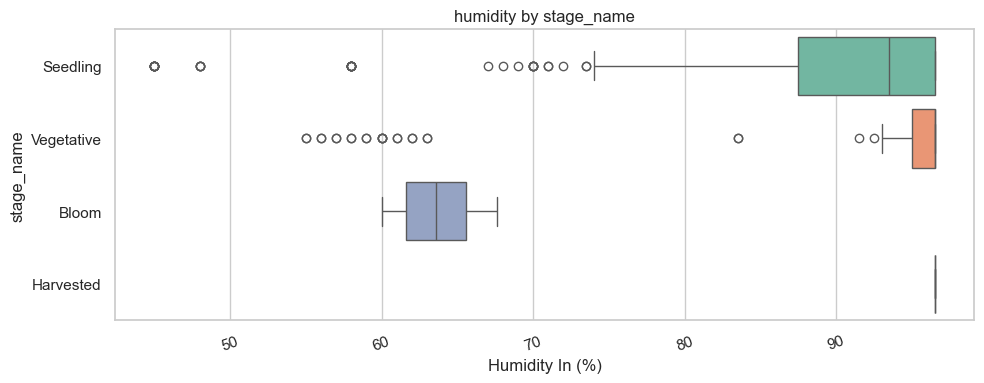

/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/3219368444.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ag, x=c, y=stage_col, palette="Set2")


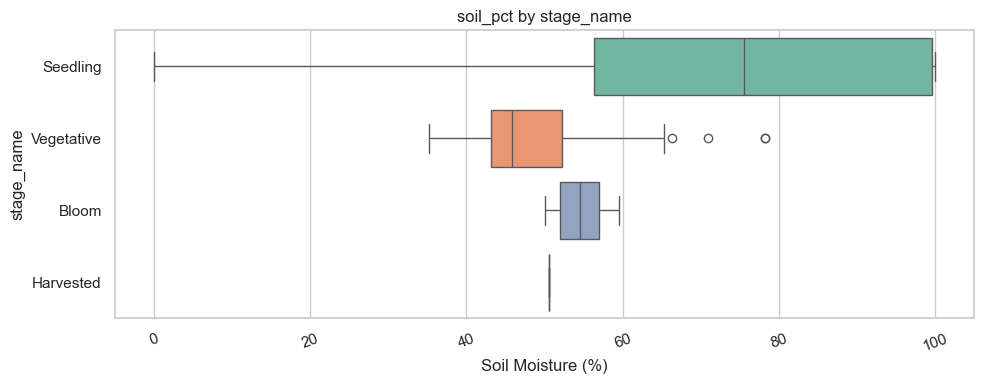

/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/3219368444.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ag, x=c, y=stage_col, palette="Set2")


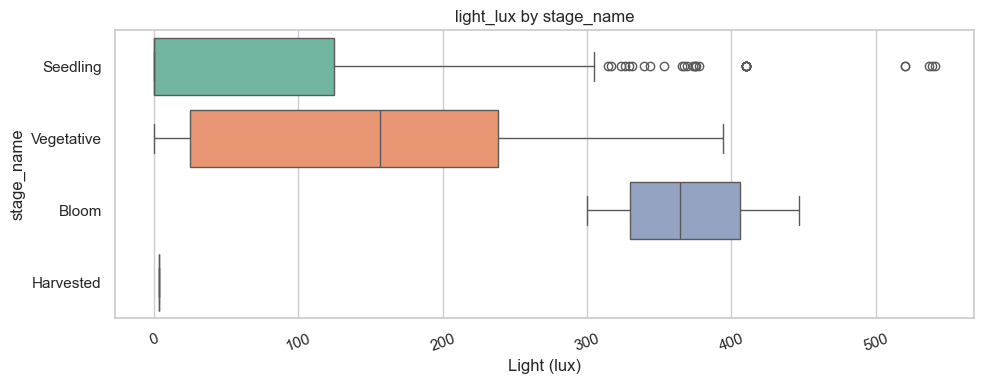

In [8]:
stage_col = col_stage_name if col_stage_name else col_stage

units = {
    col_temp_in: "Temperature In (°C)",
    col_hum_in: "Humidity In (%)",
    col_soil: "Soil Moisture (%)",
    col_light_lux: "Light (lux)",
}

if stage_col is not None:
    dist_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]
    for c in dist_cols:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=ag, x=c, y=stage_col, palette="Set2")
        plt.title(f'{c} by {stage_col}')
        plt.xticks(rotation=20)
        plt.xlabel(units.get(c, c))
        plt.tight_layout()
        plt.show()


### 3.5 Indoor vs Outdoor Comparison
**Goal:** Check enclosure isolation against outside conditions.

**What we do:** Aggregate indoor/outdoor hourly metrics and compare trends.

**Method:** hourly merge with explicit `indoor_*` and `outdoor_*` columns.


In [9]:
indoor_agg = {}
if col_temp_in:
    indoor_agg['indoor_temp'] = (col_temp_in, 'mean')
if col_hum_in:
    indoor_agg['indoor_humidity'] = (col_hum_in, 'mean')
ag_hour = ag.groupby('hour_bucket').agg(**indoor_agg).reset_index() if indoor_agg else ag[['hour_bucket']].drop_duplicates()

outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')
wh_hour = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index() if outdoor_agg else wh[['hour_bucket']].drop_duplicates()

merged_io = ag_hour.merge(wh_hour, on='hour_bucket', how='inner')
print('Indoor/outdoor merged rows:', len(merged_io))
display(merged_io.head())


Indoor/outdoor merged rows: 134


,hour_bucket,indoor_temp,indoor_humidity,outdoor_temp,outdoor_humidity
0,2026-04-13 00:00:00,31.0,96.250000,28.3,89.0
1,2026-04-13 01:00:00,31.0,96.333333,30.0,76.0
2,2026-04-13 02:00:00,31.0,96.500000,31.8,62.0
3,2026-04-13 03:00:00,31.0,96.500000,33.3,57.0
4,2026-04-13 04:00:00,31.0,96.500000,34.9,52.0


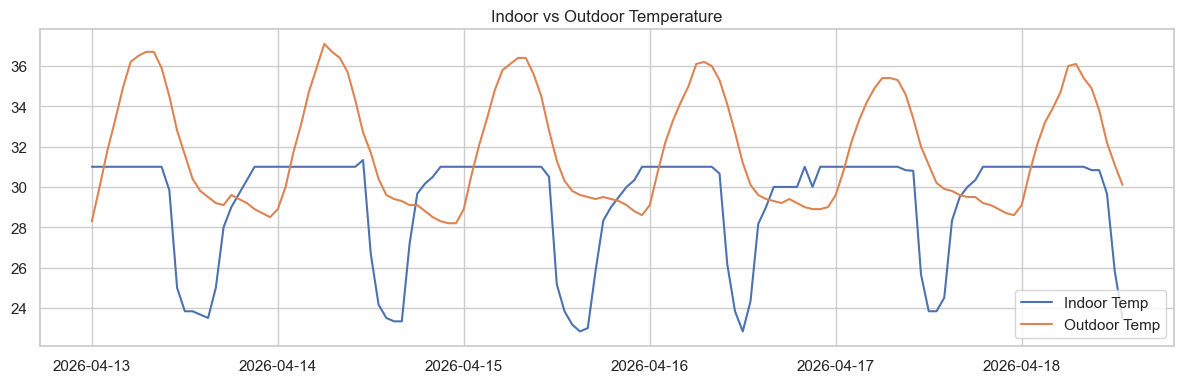

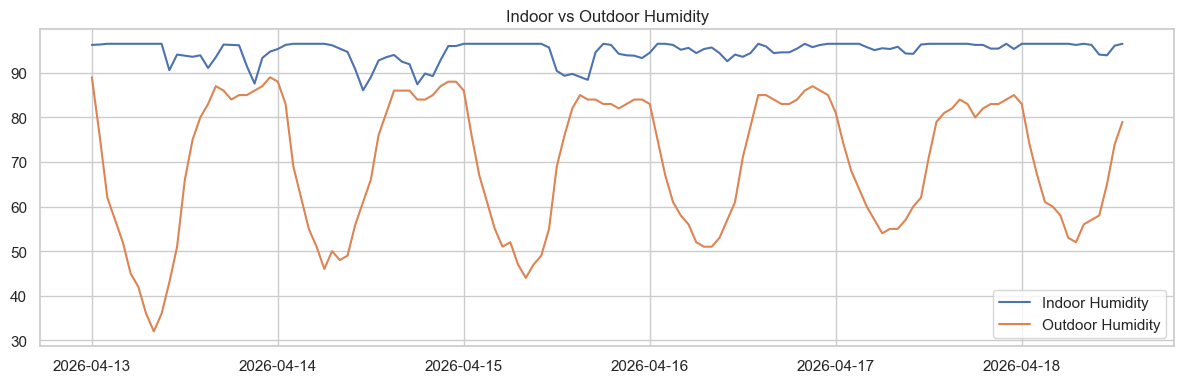

In [10]:
if 'indoor_temp' in merged_io.columns and col_temp_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_temp'], label='Indoor Temp')
    plt.plot(merged_io['hour_bucket'], merged_io[col_temp_out_feat], label='Outdoor Temp')
    plt.title('Indoor vs Outdoor Temperature')
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'indoor_humidity' in merged_io.columns and col_hum_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_humidity'], label='Indoor Humidity')
    plt.plot(merged_io['hour_bucket'], merged_io[col_hum_out_feat], label='Outdoor Humidity')
    plt.title('Indoor vs Outdoor Humidity')
    plt.legend()
    plt.tight_layout()
    plt.show()


### 3.6 Correlation Analysis
**Goal:** Identify linear relationships between numeric variables.

**What we do:** Build a correlation heatmap.

**Method:** Pearson correlation on numeric columns.


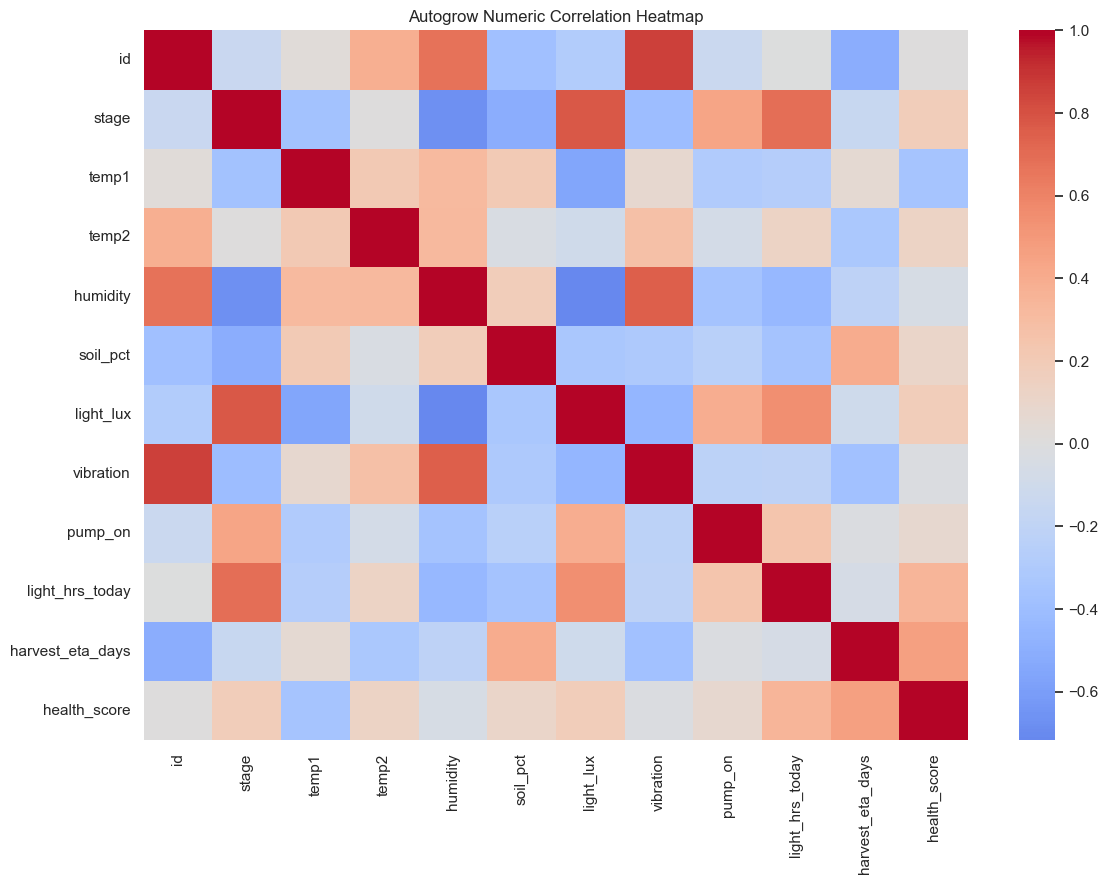

In [11]:
numeric_cols = ag.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 9))
    sns.heatmap(ag[numeric_cols].corr(), cmap='coolwarm', center=0)
    plt.title('Autogrow Numeric Correlation Heatmap')
    plt.tight_layout()
    plt.show()


## 4) Complex Data Pre-Processing Pipeline
Pipeline steps are intentionally separated for traceable outputs.


### 4.1 Timestamp Alignment Check
**Goal:** Verify time-index quality before transformation.

**What we do:** Inspect time continuity and hourly bucket readiness.

**Method:** sort by timestamp and summarize time range.


In [12]:
print('Autogrow rows:', len(ag), '| Hour buckets:', ag['hour_bucket'].nunique())
print('Weather history rows:', len(wh), '| Hour buckets:', wh['hour_bucket'].nunique())
print('Autogrow start/end:', ag['ts'].min(), '->', ag['ts'].max())
print('Weather start/end:', wh['ts'].min(), '->', wh['ts'].max())


Autogrow rows: 1569 | Hour buckets: 231
Weather history rows: 192 | Hour buckets: 192
Autogrow start/end: 2026-03-31 03:02:57 -> 2026-04-18 13:18:29
Weather start/end: 2026-04-13 00:00:00 -> 2026-04-20 23:00:00


### 4.2 Outlier Detection (IQR)
**Goal:** Detect suspicious sensor points likely to distort models.

**What we do:** Compute IQR thresholds for key columns.

**Method:** Tukey rule (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`).


In [13]:
prep = ag.copy()
outlier_cols = [c for c in [col_soil, col_temp_in] if c is not None]
outlier_stats = []

for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_stats.append({
        'column': c,
        'q1': q1,
        'q3': q3,
        'low': low,
        'high': high,
        'outlier_count': int(mask.sum())
    })

outlier_stats_df = pd.DataFrame(outlier_stats)
display(outlier_stats_df)


,column,q1,q3,low,high,outlier_count
0,soil_pct,52.5,81.8,8.55,125.75,4
1,temp1,27.1,31.0,21.25,36.85,6


### 4.3 Outlier Handling Result
**Goal:** Remove strong outliers and report impact.

**What we do:** Filter rows outside IQR limits and compare row counts.

**Method:** keep rows inside thresholds for monitored columns.


In [14]:
keep = pd.Series(True, index=prep.index)
for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    keep &= s.between(low, high) | s.isna()

prep_iqr = prep[keep].copy()
print('Rows before IQR filter:', len(prep))
print('Rows after IQR filter :', len(prep_iqr))
print('Rows removed          :', len(prep) - len(prep_iqr))


Rows before IQR filter: 1569
Rows after IQR filter : 1559
Rows removed          : 10


### 4.3b Advanced Outlier Detection: Isolation Forest (Stage 1 — Beyond Course)
**Goal:** Complement IQR filtering with an unsupervised ML-based anomaly detector.

**What we do:** Apply `IsolationForest` to all numeric sensor columns simultaneously, flag anomalous rows, and report contamination rate.

**Why this is advanced:** IQR works per-column in isolation. Isolation Forest detects *multivariate* anomalies — e.g., a row where temperature and soil moisture are each individually in range, but their *combination* is physically implausible (hardware glitch). This is the hallmark of real IoT data quality work.

**Method:** `IsolationForest(contamination=0.02, random_state=42)` on imputed sensor matrix; inlier rows feed into `prep_clean` for all downstream steps.

Isolation Forest | Features: ['soil_pct', 'temp1', 'humidity', 'light_lux']
  Total rows      : 1559
  IF Outliers     : 32 (2.05%)
  Clean inliers   : 1527


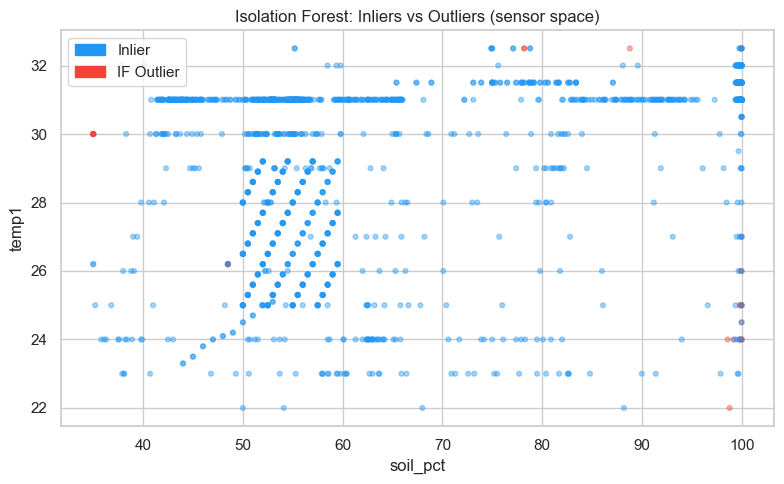


Rows after IQR + IF pipeline: 1527 (removed 32 additional rows by IF)


In [15]:
# ═══════════════════════════════════════════════════════════════
# STAGE 1: Isolation Forest — Multivariate Anomaly Detection
# ═══════════════════════════════════════════════════════════════
iso_cols = [c for c in [col_soil, col_temp_in, col_hum_in, col_light_lux]
            if c is not None and c in prep_iqr.columns]

if len(iso_cols) >= 2:
    iso_input = prep_iqr[iso_cols].copy()
    iso_imputer = SimpleImputer(strategy='median')
    iso_input_imp = iso_imputer.fit_transform(iso_input)

    iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
    iso_labels = iso_forest.fit_predict(iso_input_imp)  # 1=inlier, -1=outlier
    prep_iqr['isolation_flag'] = iso_labels

    n_outliers = (iso_labels == -1).sum()
    n_total = len(iso_labels)
    print(f'Isolation Forest | Features: {iso_cols}')
    print(f'  Total rows      : {n_total}')
    print(f'  IF Outliers     : {n_outliers} ({100*n_outliers/n_total:.2f}%)')
    print(f'  Clean inliers   : {n_total - n_outliers}')

    # Visualise: IQR-only vs IQR+IF
    import matplotlib.patches as mpatches
    colors = ['#2196F3' if v == 1 else '#F44336' for v in iso_labels]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(iso_input_imp[:, 0], iso_input_imp[:, 1],
               c=colors, alpha=0.4, s=12)
    ax.legend(handles=[
        mpatches.Patch(color='#2196F3', label='Inlier'),
        mpatches.Patch(color='#F44336', label='IF Outlier')
    ])
    ax.set_xlabel(iso_cols[0])
    ax.set_ylabel(iso_cols[1])
    ax.set_title('Isolation Forest: Inliers vs Outliers (sensor space)')
    plt.tight_layout()
    plt.show()

    prep_clean = prep_iqr[prep_iqr['isolation_flag'] == 1].drop(columns=['isolation_flag']).copy()
    print(f'\nRows after IQR + IF pipeline: {len(prep_clean)} '
          f'(removed {len(prep_iqr) - len(prep_clean)} additional rows by IF)')
else:
    print('Not enough sensor columns for Isolation Forest; using IQR-only filtered data.')
    prep_clean = prep_iqr.copy()


### 4.4 Missing-Value Audit
**Goal:** Make missingness explicit before imputation/modeling.

**What we do:** Show null counts after outlier filtering.

**Method:** column-wise `isna().sum()`.


In [16]:
# Null audit after full cleaning pipeline (IQR + Isolation Forest)
nulls_after_clean = prep_clean.isna().sum().sort_values(ascending=False)
display(nulls_after_clean[nulls_after_clean > 0].to_frame('null_count'))
print(f'Rows in prep_clean: {len(prep_clean)}')


,null_count


Rows in prep_clean: 1527


### 4.5 Multi-Source Fusion
**Goal:** Combine indoor and outdoor context into one modeling table.

**What we do:** Merge `prep_iqr` with hourly outdoor weather + daylight hours.

**Method:** join on `hour_bucket` and daily date keys.


In [17]:
feat = prep_clean.copy()

outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')

if outdoor_agg:
    wh_hourly_feat = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index()
    feat = feat.merge(wh_hourly_feat, on='hour_bucket', how='left')
else:
    feat[col_temp_out_feat] = np.nan
    feat[col_hum_out_feat] = np.nan

col_sunrise = first_existing(wc.columns, ['sunrise_utc', 'sunrise'])
col_sunset = first_existing(wc.columns, ['sunset_utc', 'sunset'])
if col_sunrise and col_sunset:
    wc_tmp = wc.copy()
    wc_tmp['sunrise_dt'] = pd.to_datetime(wc_tmp[col_sunrise], errors='coerce', utc=True).dt.tz_localize(None)
    wc_tmp['sunset_dt'] = pd.to_datetime(wc_tmp[col_sunset], errors='coerce', utc=True).dt.tz_localize(None)
    wc_tmp['daylight_hours'] = (wc_tmp['sunset_dt'] - wc_tmp['sunrise_dt']).dt.total_seconds() / 3600
    if 'ts' in wc_tmp.columns and wc_tmp['ts'].notna().any():
        wc_tmp['date'] = wc_tmp['ts'].dt.date
    else:
        wc_tmp['date'] = wc_tmp['sunrise_dt'].dt.date
    daylight_df = wc_tmp.groupby('date', as_index=False)['daylight_hours'].mean()
    feat['date'] = feat['ts'].dt.date
    feat = feat.merge(daylight_df, on='date', how='left')
else:
    feat['daylight_hours'] = np.nan

print('Feature table shape after merge:', feat.shape)
display(feat.head())


Feature table shape after merge: (1527, 21)


,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score,hour_bucket,outdoor_temp,outdoor_humidity,date,daylight_hours
0,10,2026-03-31 03:13:40,0,Seedling,OFF,26.2,0.0,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
1,176,2026-03-31 03:13:40,0,Seedling,,26.2,26.2,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
2,11,2026-03-31 03:13:46,0,Seedling,OFF,26.2,0.0,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
3,177,2026-03-31 03:13:46,0,Seedling,,26.2,26.2,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,NaN,NaN,2026-03-31,NaN
4,181,2026-04-06 16:39:46,0,Seedling,,31.5,31.5,82.5,87.1,0.0,0,0,OK,0.0,0,0,2026-04-06 16:00:00,NaN,NaN,2026-04-06,NaN


### 4.6 Feature Engineering
**Goal:** Create domain-informed predictive features.

**What we do:** Build `soil_deviation`, `temp_delta`, `light_deficit`, and cyclical hour.

**Method:** stage-specific targets + arithmetic transforms + sin/cos encoding.


In [18]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col:
    feat['stage_label'] = feat[stage_col].astype(str)
else:
    feat['stage_label'] = 'unknown'

stage_key = feat['stage_label'].str.lower().str.strip()

if col_soil:
    soil_target_map = {'seedling': 70, 'vegetative': 60, 'bloom': 50, 'harvested': 40}
    feat['soil_target'] = stage_key.map(soil_target_map).fillna(60)
    feat['soil_deviation'] = pd.to_numeric(feat[col_soil], errors='coerce') - feat['soil_target']

if col_temp_in and col_temp_out_feat in feat.columns:
    feat['temp_delta'] = pd.to_numeric(feat[col_temp_in], errors='coerce') - pd.to_numeric(feat[col_temp_out_feat], errors='coerce')

if col_light_hrs:
    light_target_map = {'seedling': 6, 'vegetative': 12, 'bloom': 12, 'harvested': 0}
    feat['light_target'] = stage_key.map(light_target_map).fillna(12)
    feat['light_deficit'] = feat['light_target'] - pd.to_numeric(feat[col_light_hrs], errors='coerce')

feat['hour'] = feat['ts'].dt.hour
feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24)
feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24)

preview_cols = [c for c in [
    'ts', 'stage_label', col_temp_in, col_hum_in, col_soil, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    'soil_deviation', 'temp_delta', 'light_deficit', 'hour_sin', 'hour_cos', 'daylight_hours'
] if c is not None and c in feat.columns]
display(feat[preview_cols].head())


,ts,stage_label,temp1,humidity,soil_pct,light_hrs_today,outdoor_temp,outdoor_humidity,soil_deviation,temp_delta,light_deficit,hour_sin,hour_cos,daylight_hours
0,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,NaN,NaN,-21.5,NaN,6.0,0.707107,0.707107,NaN
1,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,NaN,NaN,-21.5,NaN,6.0,0.707107,0.707107,NaN
2,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,NaN,NaN,-35.0,NaN,6.0,0.707107,0.707107,NaN
3,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,NaN,NaN,-35.0,NaN,6.0,0.707107,0.707107,NaN
4,2026-04-06 16:39:46,Seedling,31.5,82.5,87.1,0.0,NaN,NaN,17.1,NaN,6.0,-0.866025,-0.500000,NaN


### 4.7 Imbalance Handling Setup
**Goal:** Prepare strategy for imbalanced stage labels.

**What we do:** Show class counts and check SMOTE availability.

**Method:** use SMOTE when available, otherwise class-weighted models.


In [19]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    print('No stage target found, skip imbalance setup.')
else:
    counts = feat[stage_col].astype(str).value_counts()
    print('Class counts before balancing:')
    print(counts)

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
    print('SMOTE available: True')
except Exception as e:
    smote_available = False
    print('SMOTE available: False (fallback to class_weight)')
    print('Reason:', str(e))


Class counts before balancing:
stage_name
Seedling      895
Bloom         336
Vegetative    295
Harvested       1
Name: count, dtype: int64
SMOTE available: False (fallback to class_weight)
Reason: No module named 'imblearn'


## 5) Analytics Technique (Beyond Course): Random Forest + SHAP
### 5.1 Build Time-Based Train/Test Sets
**Goal:** Avoid temporal leakage in evaluation.

**What we do:** Split by date (or 80% time quantile fallback).

**Method:** train on earlier timestamps, test on later timestamps.


In [20]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    raise ValueError('No stage label found for classification task.')

model_df = feat.dropna(subset=['ts']).sort_values('ts').copy()
model_df['target_stage'] = model_df[stage_col].astype(str)

vc = model_df['target_stage'].value_counts()
valid_classes = vc[vc >= 5].index
model_df = model_df[model_df['target_stage'].isin(valid_classes)].copy()

feature_candidates = [
    col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    'soil_deviation', 'temp_delta', 'light_deficit',
    'hour_sin', 'hour_cos', 'daylight_hours'
]
X_cols = [c for c in feature_candidates if c is not None and c in model_df.columns]

cutoff = pd.Timestamp('2026-04-15')
if model_df['ts'].min() < cutoff < model_df['ts'].max():
    split_ts = cutoff
else:
    split_ts = model_df['ts'].quantile(0.8)

train_mask = model_df['ts'] < split_ts
test_mask = model_df['ts'] >= split_ts

X_train = model_df.loc[train_mask, X_cols].copy()
X_test = model_df.loc[test_mask, X_cols].copy()
y_train = model_df.loc[train_mask, 'target_stage'].copy()
y_test = model_df.loc[test_mask, 'target_stage'].copy()

print('Rows:', len(model_df), '| Train:', len(X_train), '| Test:', len(X_test), '| Split:', split_ts)
print('Features:', X_cols)
print('Train class counts:')
print(y_train.value_counts())


Rows: 1526 | Train: 1013 | Test: 513 | Split: 2026-04-15 00:00:00
Features: ['temp1', 'humidity', 'soil_pct', 'light_lux', 'light_hrs_today', 'outdoor_temp', 'outdoor_humidity', 'soil_deviation', 'temp_delta', 'light_deficit', 'hour_sin', 'hour_cos', 'daylight_hours']
Train class counts:
target_stage
Seedling      657
Bloom         336
Vegetative     20
Name: count, dtype: int64


### 5.2 Optional SMOTE (Train Only)
**Goal:** Reduce class imbalance in the training subset only.

**What we do:** Apply SMOTE after median imputation.

**Method:** synthetic minority oversampling with safe `k_neighbors`.


In [21]:
X_train_bal, y_train_bal = X_train.copy(), y_train.copy()

# Always impute first so X_train_bal has no NaNs (required by XGBoost too)
_smote_imputer = SimpleImputer(strategy='median')
X_train_imp_arr = _smote_imputer.fit_transform(X_train_bal)

# Drop all-NaN columns that imputer couldn't fill (e.g. daylight_hours if missing)
_valid_mask = ~np.all(np.isnan(_smote_imputer.statistics_[:, None] * 0 +
                               _smote_imputer.statistics_[:, None]), axis=1) \
              if False else slice(None)  # placeholder; real check below
_good_cols = [c for c, stat in zip(X_cols, _smote_imputer.statistics_)
              if not np.isnan(stat)]
X_cols_clean = _good_cols  # authoritative column list from here onwards
X_cols = X_cols_clean      # update global X_cols to match

X_train_imp = pd.DataFrame(
    X_train_imp_arr[:, [X_cols.index(c) for c in X_cols_clean]] if len(X_cols_clean) < len(X_train_bal.columns)
    else X_train_imp_arr,
    columns=X_cols_clean,
    index=X_train_bal.index
)

if 'smote_available' in globals() and smote_available:
    min_class = y_train_bal.value_counts().min()
    k_neighbors = max(1, min(5, int(min_class) - 1))
    if min_class > 1 and k_neighbors >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_bal_arr, y_bal_arr = sm.fit_resample(X_train_imp, y_train_bal)
        X_train_bal = pd.DataFrame(X_bal_arr, columns=X_cols_clean)
        y_train_bal = pd.Series(y_bal_arr)
        print('Applied SMOTE. Balanced class counts:')
        print(y_train_bal.value_counts())
    else:
        X_train_bal = X_train_imp.copy()
        print('SMOTE skipped: not enough samples in smallest class.')
else:
    X_train_bal = X_train_imp.copy()
    print('SMOTE not available; using imputed training data.')

# Also align X_test to the same clean columns
X_test = X_test[X_cols_clean].copy()
print(f'X_train_bal shape: {X_train_bal.shape}  X_test shape: {X_test.shape}')
print(f'Active features ({len(X_cols_clean)}): {X_cols_clean}')


SMOTE not available; using imputed training data.
X_train_bal shape: (1013, 12)  X_test shape: (513, 12)
Active features (12): ['temp1', 'humidity', 'soil_pct', 'light_lux', 'light_hrs_today', 'outdoor_temp', 'outdoor_humidity', 'soil_deviation', 'temp_delta', 'light_deficit', 'hour_sin', 'hour_cos']


/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['daylight_hours']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 5a) Stage 2: XGBoost + TimeSeriesSplit (Advanced Modeling — Beyond Course)

### 5a.1 Motivation

**Goal:** Replace standard k-fold CV with time-aware validation and add gradient boosting.

**Why TimeSeriesSplit?** Standard k-fold shuffles rows randomly, causing *temporal leakage* — the model effectively sees the future during training. `TimeSeriesSplit` always trains on chronologically earlier data and validates on later data, mirroring real deployment.

**Why XGBoost?** Random Forest grows trees in parallel (bagging). XGBoost grows trees *sequentially*, with each tree correcting the errors of the previous one (gradient boosting). This typically yields higher accuracy on structured tabular data.

**Method:** 5-fold `TimeSeriesSplit` on the training set → final holdout evaluation → results added to the master comparison table.

TimeSeriesSplit CV F1-macro per fold: [1.     1.     0.4985 1.     1.    ]
Mean: 0.8997  Std: 0.2006


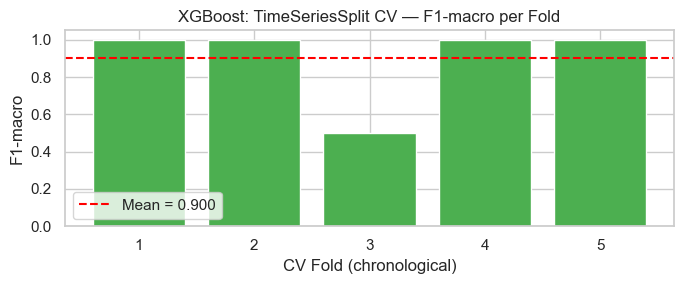


XGBoost Holdout F1-macro: 0.3169
              precision    recall  f1-score   support

    Seedling       0.46      1.00      0.63       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.23      0.50      0.32       513
weighted avg       0.22      0.46      0.29       513



/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

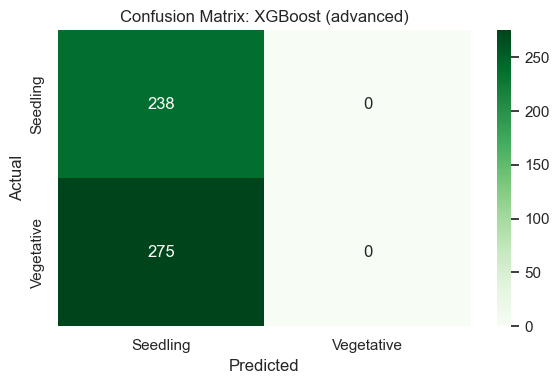

,model,f1_macro
0,XGBoost (advanced),0.316911


XGBoost stored in fitted_models.


In [22]:
# ═══════════════════════════════════════════════════════════════
# STAGE 2: XGBoost + TimeSeriesSplit Cross-Validation
# Depends on: X_train_bal, y_train_bal, X_test (all aligned by 5.2)
# ═══════════════════════════════════════════════════════════════
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder

# X_train_bal is already imputed and column-aligned by the SMOTE cell.
# X_test was aligned to the same columns there too.
# Just impute X_test (train stats used only for imputation)
_xgb_imputer = SimpleImputer(strategy='median')
_xgb_imputer.fit(X_train_bal)  # fit on train
X_train_cv = pd.DataFrame(
    _xgb_imputer.transform(X_train_bal),
    columns=X_train_bal.columns
)
X_test_cv = pd.DataFrame(
    _xgb_imputer.transform(X_test),
    columns=X_train_bal.columns
)

# Encode string labels → integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bal.astype(str))
y_test_str  = y_test.astype(str)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# ── TimeSeriesSplit CV ────────────────────────────────────────────
n_splits = min(5, max(2, len(X_train_cv) - 1))
tscv = TimeSeriesSplit(n_splits=n_splits)
cv_scores = cross_val_score(
    xgb_clf, X_train_cv, y_train_enc,
    cv=tscv, scoring='f1_macro'
)
print('TimeSeriesSplit CV F1-macro per fold:', np.round(cv_scores, 4))
print(f'Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}')

plt.figure(figsize=(7, 3))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, color='#4CAF50')
plt.axhline(cv_scores.mean(), linestyle='--', color='red',
            label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('CV Fold (chronological)')
plt.ylabel('F1-macro')
plt.title('XGBoost: TimeSeriesSplit CV — F1-macro per Fold')
plt.legend()
plt.tight_layout()
plt.show()

# ── Final fit → holdout evaluation ───────────────────────────────
xgb_clf.fit(X_train_cv, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb_clf.predict(X_test_cv))

xgb_f1 = f1_score(y_test_str, y_pred_xgb, average='macro')
print(f'\nXGBoost Holdout F1-macro: {xgb_f1:.4f}')
print(classification_report(y_test_str, y_pred_xgb))

labels_xgb = sorted(y_test_str.unique())
cm_xgb = confusion_matrix(y_test_str, y_pred_xgb, labels=labels_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_xgb, yticklabels=labels_xgb)
plt.title('Confusion Matrix: XGBoost (advanced)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Add to master results table ───────────────────────────────────
xgb_row = pd.DataFrame([{'model': 'XGBoost (advanced)', 'f1_macro': xgb_f1}])
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    results_df = pd.concat(
        [results_df[results_df['model'] != 'XGBoost (advanced)'], xgb_row],
        ignore_index=True
    ).sort_values('f1_macro', ascending=False).reset_index(drop=True)
else:
    results_df = xgb_row.copy()
display(results_df)

# Store model + imputer + label encoder for SHAP
if 'fitted_models' not in globals():
    fitted_models = {}
fitted_models['XGBoost (advanced)'] = (xgb_clf, _xgb_imputer, le)
print('XGBoost stored in fitted_models.')


### 5.3 Train Models and Compare
**Goal:** Compare course baselines vs advanced method.

**What we do:** Train Decision Tree, k-NN, Random Forest.

**Method:** macro-F1 + confusion matrix on time-based holdout set.



Decision Tree (baseline) | F1-macro=0.2365
              precision    recall  f1-score   support

       Bloom       0.00      0.00      0.00         0
    Seedling       0.55      1.00      0.71       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.18      0.33      0.24       513
weighted avg       0.26      0.46      0.33       513



/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

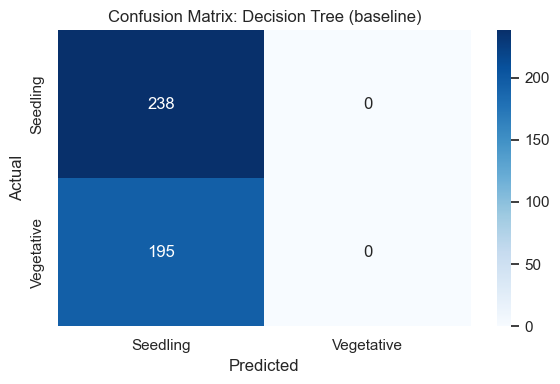


k-NN (baseline) | F1-macro=0.3169
              precision    recall  f1-score   support

    Seedling       0.46      1.00      0.63       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.23      0.50      0.32       513
weighted avg       0.22      0.46      0.29       513



/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

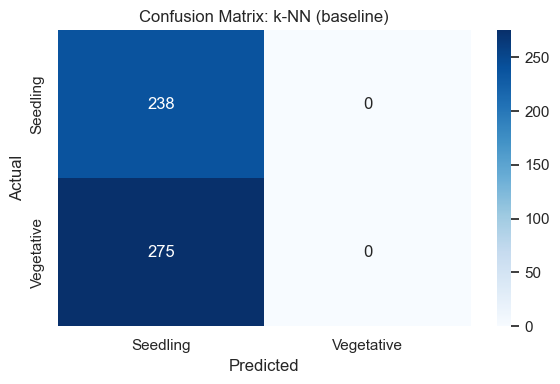


Random Forest (advanced) | F1-macro=0.3169
              precision    recall  f1-score   support

    Seedling       0.46      1.00      0.63       238
  Vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.23      0.50      0.32       513
weighted avg       0.22      0.46      0.29       513



/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

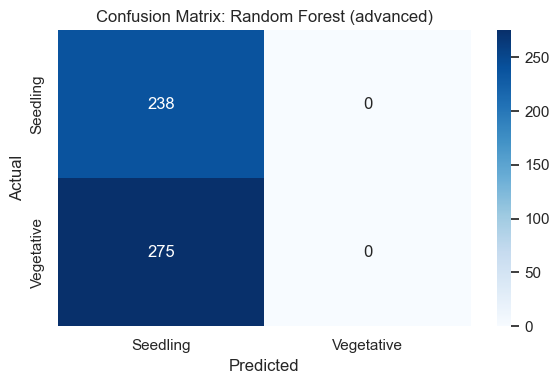

,model,f1_macro
1,k-NN (baseline),0.316911
2,Random Forest (advanced),0.316911
0,Decision Tree (baseline),0.236463


Best model by F1-macro: k-NN (baseline)


In [23]:
models = {
    'Decision Tree (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42))
    ]),
    'k-NN (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Random Forest (advanced)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42))
    ])
}

results = []
fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train_bal, y_train_bal)
    pred = pipe.predict(X_test)
    f1 = f1_score(y_test, pred, average='macro')
    results.append({'model': name, 'f1_macro': f1})
    fitted_models[name] = pipe

    print(f'\n{name} | F1-macro={f1:.4f}')
    print(classification_report(y_test, pred))

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
display(results_df)
if not results_df.empty:
    print('Best model by F1-macro:', results_df.iloc[0]['model'])


### 5.4 SHAP Interpretability — Stage 3: The 'Why' (Advanced)

**Goal:** Decode which features drive growth-stage predictions in the winning model.

**What we do:** Apply SHAP `TreeExplainer` to the best model (XGBoost or RF), produce a bar summary (global importance) and a beeswarm (per-class direction).

**Why this matters for agriculture:** A black-box model that says 'Bloom stage' is not actionable. SHAP shows *which sensors* drove that prediction and *by how much*, enabling growers to take targeted interventions (e.g., adjust irrigation if `soil_deviation` dominates).

**Method:** SHAP `TreeExplainer` on imputed test subset (n ≤ 300 for speed).

Best model: k-NN (baseline) — applying SHAP


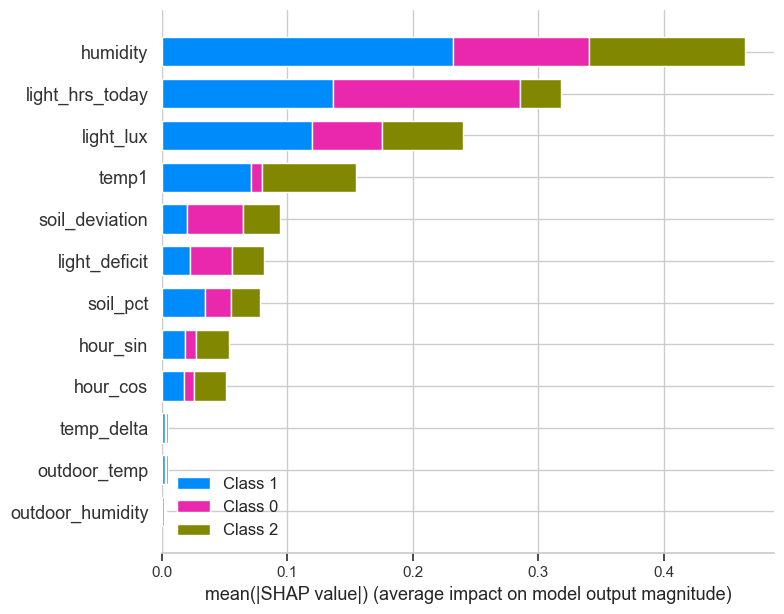

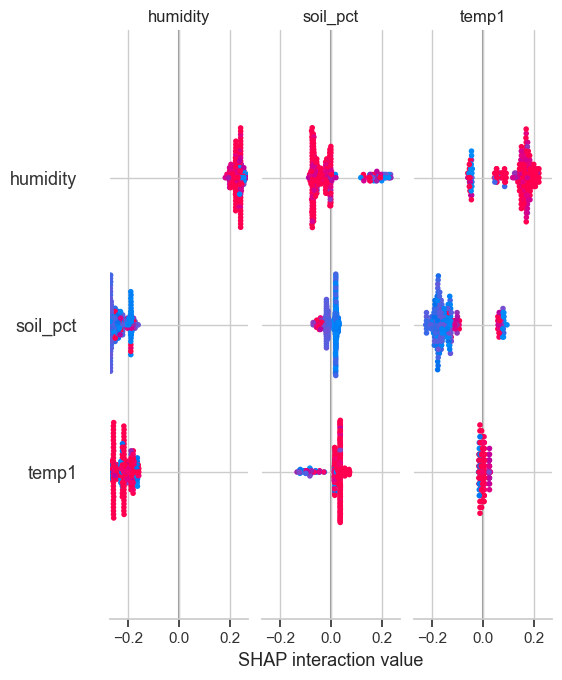

In [24]:
# ═══════════════════════════════════════════════════════════════
# STAGE 3: SHAP Interpretability — applied to the best model
# ═══════════════════════════════════════════════════════════════
import shap

# Pick best model
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    best_name = results_df.sort_values('f1_macro', ascending=False).iloc[0]['model']
else:
    best_name = 'Random Forest (advanced)'
print(f'Best model: {best_name} — applying SHAP')

try:
    if best_name == 'XGBoost (advanced)' and 'XGBoost (advanced)' in fitted_models:
        xgb_model, xgb_imp, xgb_le = fitted_models['XGBoost (advanced)']
        # Use same columns XGBoost was trained on
        shap_cols = list(X_train_bal.columns)
        X_test_shap = pd.DataFrame(
            xgb_imp.transform(X_test[shap_cols]),
            columns=shap_cols
        )
        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap

        explainer = shap.TreeExplainer(xgb_model)
        shap_vals = explainer.shap_values(X_shap)

        print('SHAP Bar Summary (mean |SHAP| across all classes):')
        shap.summary_plot(shap_vals, X_shap, plot_type='bar', show=True)
        print('SHAP Beeswarm (class-level feature impact):')
        shap.summary_plot(shap_vals, X_shap, show=True)

    elif 'Random Forest (advanced)' in fitted_models:
        rf_pipe = fitted_models['Random Forest (advanced)']
        rf_imputer = rf_pipe.named_steps['imputer']
        rf_model   = rf_pipe.named_steps['model']
        shap_cols = list(X_train_bal.columns)
        X_test_shap = pd.DataFrame(
            rf_imputer.transform(X_test[shap_cols]),
            columns=shap_cols
        )
        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap
        explainer = shap.TreeExplainer(rf_model)
        shap_vals = explainer.shap_values(X_shap)
        shap.summary_plot(shap_vals, X_shap, plot_type='bar', show=True)
        shap.summary_plot(shap_vals, X_shap, show=True)

    else:
        print('No fitted tree model found. Run Sections 5a and 5.3 first.')

except Exception as e:
    print('SHAP error:', e)
    print('Tip: pip install shap')


## 6) Evaluation Summary (Main Task)
**Goal:** Create presentation-ready model comparison.

**What we do:** Plot macro-F1 scores.

**Method:** bar plot from `results_df`.


/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_6617/3902869204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x='model', y='f1_macro', palette=colors)


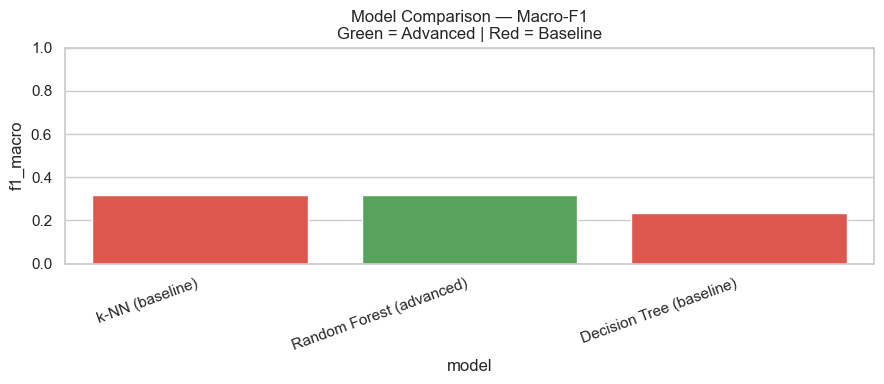

,model,f1_macro
0,k-NN (baseline),0.316911
1,Random Forest (advanced),0.316911
2,Decision Tree (baseline),0.236463


Best model: k-NN (baseline) (F1 = 0.3169)


In [25]:
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    final_df = results_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)
    colors = ['#F44336' if 'baseline' in m else '#4CAF50' for m in final_df['model']]
    plt.figure(figsize=(9, 4))
    sns.barplot(data=final_df, x='model', y='f1_macro', palette=colors)
    plt.title('Model Comparison — Macro-F1\nGreen = Advanced | Red = Baseline')
    plt.ylim(0, 1)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    display(final_df)
    print('Best model:', final_df.iloc[0]['model'],
          f"(F1 = {final_df.iloc[0]['f1_macro']:.4f})")
else:
    print('Run Sections 5.3 and 5a first to populate results.')


## 7) Optional Supporting Tasks
These are optional support analyses from the original plan.


### 7.1 Health Score Regression (Optional)
**Goal:** Predict health score from engineered features.

**What we do:** Compare simple regression baselines.

**Method:** MAE and RMSE on time-based split.


In [26]:
if col_health and col_health in feat.columns:
    reg_df = feat.dropna(subset=['ts']).sort_values('ts').copy()
    X_cols_reg = [c for c in [
        col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
        col_temp_out_feat, col_hum_out_feat,
        'soil_deviation', 'temp_delta', 'light_deficit',
        'hour_sin', 'hour_cos', 'daylight_hours'
    ] if c is not None and c in reg_df.columns]

    cutoff = pd.Timestamp('2026-04-15')
    split_ts = cutoff if reg_df['ts'].min() < cutoff < reg_df['ts'].max() else reg_df['ts'].quantile(0.8)
    train_mask = reg_df['ts'] < split_ts

    X_train_reg = reg_df.loc[train_mask, X_cols_reg]
    X_test_reg = reg_df.loc[~train_mask, X_cols_reg]
    y_train_reg = reg_df.loc[train_mask, col_health]
    y_test_reg = reg_df.loc[~train_mask, col_health]

    reg_models = {
        'Linear Regression': LinearRegression(),
        'Decision Tree Regressor': DecisionTreeRegressor(max_depth=6, random_state=42),
        'k-NN Regressor': KNeighborsRegressor(n_neighbors=7),
    }

    reg_rows = []
    for name, model in reg_models.items():
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        pipe.fit(X_train_reg, y_train_reg)
        pred = pipe.predict(X_test_reg)
        mae = mean_absolute_error(y_test_reg, pred)
        rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
        reg_rows.append({'model': name, 'mae': mae, 'rmse': rmse})
        print(f'{name}: MAE={mae:.4f}, RMSE={rmse:.4f}')

    display(pd.DataFrame(reg_rows).sort_values('mae'))
else:
    print('health_score not found; skip regression task.')


Linear Regression: MAE=8.8663, RMSE=10.6318
Decision Tree Regressor: MAE=9.0560, RMSE=20.5682
k-NN Regressor: MAE=7.0292, RMSE=12.3186


/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['daylight_hours']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['daylight_hours']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['daylight_hours']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any ob

,model,mae,rmse
2,k-NN Regressor,7.029183,12.318584
0,Linear Regression,8.866314,10.631840
1,Decision Tree Regressor,9.055969,20.568226


### 7.2 Pump Operation Detection (Optional)
**Goal:** Detect pump ON/OFF (not failure) from available sensor signals.

**What we do:** Build binary pump target and evaluate simple classifiers.

**Method:** Decision Tree and k-NN with macro-F1.


In [27]:
pump_df = feat.dropna(subset=['ts']).sort_values('ts').copy()

pump_target = None
if 'pump_on' in pump_df.columns:
    pump_target = pd.to_numeric(pump_df['pump_on'], errors='coerce')
elif col_pump_status and col_pump_status in pump_df.columns:
    status = pump_df[col_pump_status].astype(str).str.lower().str.strip()
    pump_target = (~status.isin(['idle', 'off', '0', 'false', 'none'])).astype(int)

if pump_target is None:
    print('No pump status found; skip pump task.')
else:
    pump_df['pump_target'] = pump_target
    pump_features = [c for c in [col_vibration, col_soil] if c is not None and c in pump_df.columns]

    if not pump_features:
        print('No pump features found (vibration/soil); skip pump task.')
    else:
        cutoff = pd.Timestamp('2026-04-15')
        split_ts = cutoff if pump_df['ts'].min() < cutoff < pump_df['ts'].max() else pump_df['ts'].quantile(0.8)
        tr = pump_df['ts'] < split_ts

        Xtr, Xte = pump_df.loc[tr, pump_features], pump_df.loc[~tr, pump_features]
        ytr, yte = pump_df.loc[tr, 'pump_target'], pump_df.loc[~tr, 'pump_target']

        pump_models = {
            'Decision Tree': DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
            'k-NN': KNeighborsClassifier(n_neighbors=7),
        }

        for name, model in pump_models.items():
            pipe = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', model)
            ])
            pipe.fit(Xtr, ytr)
            pred = pipe.predict(Xte)
            f1 = f1_score(yte, pred, average='macro')
            print(f'\n{name}: F1-macro={f1:.4f}')
            print(classification_report(yte, pred))



Decision Tree: F1-macro=0.4891
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       492
           1       0.00      0.00      0.00        22

    accuracy                           0.96       514
   macro avg       0.48      0.50      0.49       514
weighted avg       0.92      0.96      0.94       514


k-NN: F1-macro=0.4891
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       492
           1       0.00      0.00      0.00        22

    accuracy                           0.96       514
   macro avg       0.48      0.50      0.49       514
weighted avg       0.92      0.96      0.94       514



/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Mark/SKE/DA/AutoGrow_DataAnalytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

## 8) Demo and Deliverables Checklist
For presentation/report screenshots, capture:
1. 3-table loading output
2. EDA charts (time-series, class imbalance, indoor/outdoor)
3. Preprocessing outputs (IQR table, missing audit, engineered features)
4. Model comparison table + confusion matrix
5. SHAP summary plot


## 9) References
- Scikit-learn docs: Decision Tree, k-NN, Random Forest, IsolationForest, TimeSeriesSplit
- XGBoost docs: https://xgboost.readthedocs.io
- imbalanced-learn docs (SMOTE): https://imbalanced-learn.org
- SHAP docs: https://shap.readthedocs.io
- Open-Meteo API docs: https://open-meteo.com
- Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation Forest*. ICDM 2008.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016.
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017.
